# Importação do .csv tratado

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../db/clean/bilheteria-distribuidoras.csv')
df.head()

,data_exibicao,titulo,cpb_roe,pais_obra,publico,uf_sala_complexo,razao_social_distribuidora
0,2014-01-01,UM TOQUE DE PECADO,E1600132700000,CHINA,16,RS,SM DISTRIBUIDORA DE FILMES LTDA
1,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,14,SP,COLUMBIA TRISTAR FILMES DO BRASIL LTDA
2,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,60,SP,COLUMBIA TRISTAR FILMES DO BRASIL LTDA
3,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,0,SC,COLUMBIA TRISTAR FILMES DO BRASIL LTDA
4,2014-01-01,QUESTÃO DE TEMPO,E1402624700000,ESTADOS UNIDOS,0,SP,COLUMBIA TRISTAR FILMES DO BRASIL LTDA


## Análise de filmes distribuidos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18753513 entries, 0 to 18753512
Data columns (total 7 columns):
 #   Column                      Dtype 
---  ------                      ----- 
 0   data_exibicao               object
 1   titulo                      object
 2   cpb_roe                     object
 3   pais_obra                   object
 4   publico                     int64 
 5   uf_sala_complexo            object
 6   razao_social_distribuidora  object
dtypes: int64(1), object(6)
memory usage: 1001.5+ MB


In [4]:
df['tipo_filme'] = df['cpb_roe'].apply(lambda x: 'Estrangeiro' if str(x).startswith('E') else 'Brasileiro')

In [5]:
df['data_exibicao'] = pd.to_datetime(df['data_exibicao'])
df['ano'] = df['data_exibicao'].dt.year

### Filmes estrangeiros x brasileiros

In [6]:
df['tipo_filme'].value_counts()

tipo_filme
Estrangeiro    16342224
Brasileiro      2411289
Name: count, dtype: int64

### Filmes únicos distribuidos por país

In [21]:
df.groupby('pais_obra')['cpb_roe'].nunique().sort_values(ascending=False)

pais_obra
BRASIL                             1753
ESTADOS UNIDOS                     1601
FRANÇA                              489
ALEMANHA                            214
BÉLGICA                             123
                                   ... 
NOVA ZELÂNDIA                         1
MACEDÔNIA (REPÚBLICA YUGOSLAVA)       1
TAIWAN                                1
TERRITÓRIOS PALESTINOS OCUPADOS       1
TUNÍSIA                               1
Name: cpb_roe, Length: 81, dtype: int64

### Filmes estrangeiros x brasileiros por ano

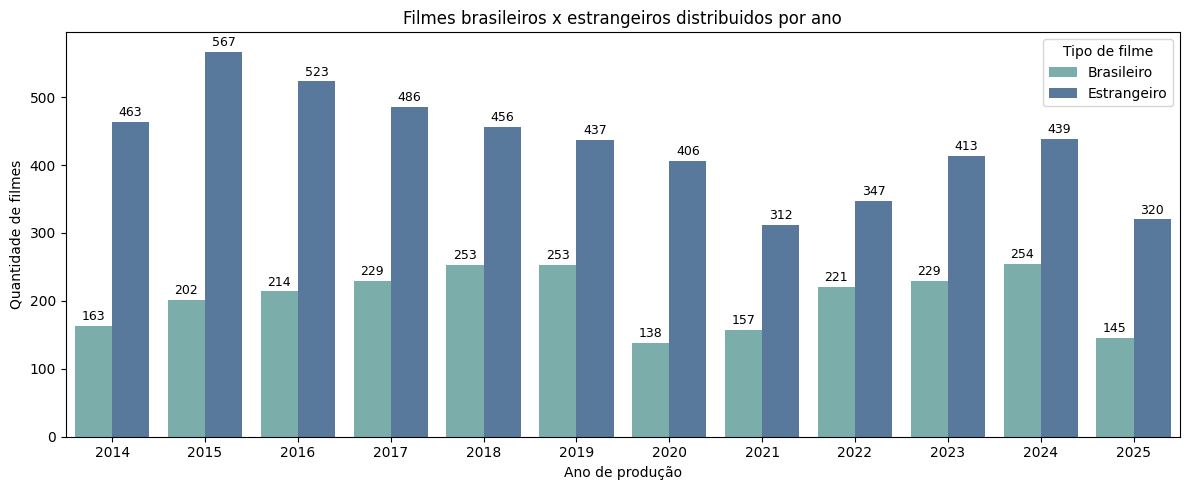

In [36]:
df_unique = (
    df.drop_duplicates(subset=['ano', 'cpb_roe'])
)

contagem = (
    df_unique.groupby(['ano', 'tipo_filme'])
             .size()
             .reset_index(name='count')
)

anos_ord = sorted(contagem['ano'].unique())

plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=contagem,
    x='ano',
    y='count',
    hue='tipo_filme',
    order=anos_ord,
    palette=['#72B7B2','#4C78A8']
)

ax.set_xlabel('Ano de produção')
ax.set_ylabel('Quantidade de filmes')
ax.set_title('Filmes brasileiros x estrangeiros distribuidos por ano')

# Rótulos com contagem absoluta
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=9)

plt.legend(title='Tipo de filme')
plt.tight_layout()
plt.show()

### Comparação entre público de filmes brasileiros e de filmes estrangeiros

In [10]:
publico_total = df.groupby('tipo_filme')['publico'].sum()
print(publico_total)

tipo_filme
Brasileiro      169030886
Estrangeiro    1341669651
Name: publico, dtype: int64


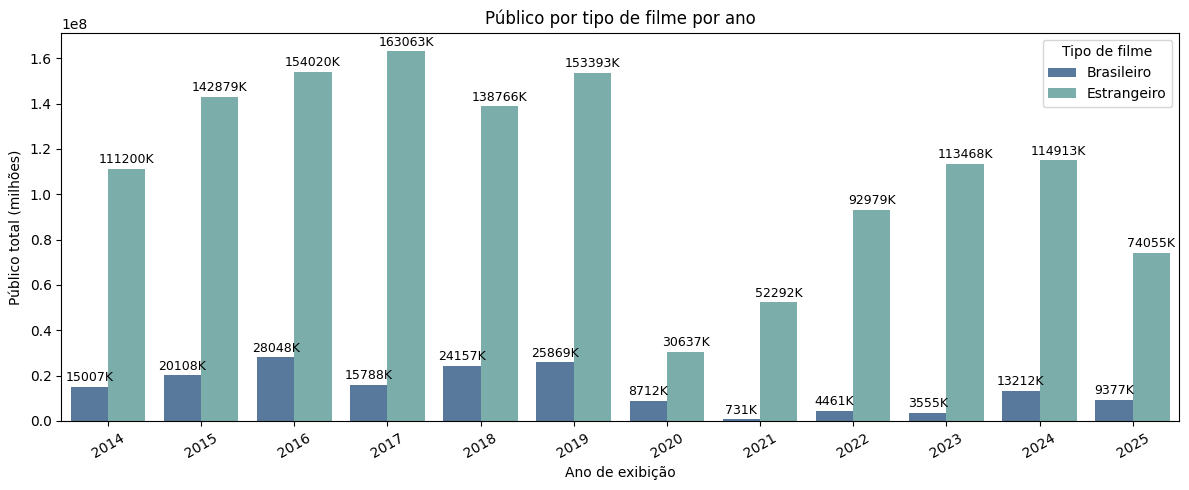

In [11]:
publico_por_ano = df.groupby(['ano', 'tipo_filme'])['publico'].sum().reset_index()

plt.figure(figsize=(12,5))
ax = sns.barplot(data=publico_por_ano, x='ano', y='publico', hue='tipo_filme', palette=['#4C78A8', '#72B7B2'])

ax.set_xlabel('Ano de exibição')
ax.set_ylabel('Público total (milhões)')
ax.set_title('Público por tipo de filme por ano')

# Rótulos no topo das barras em milhares
for container in ax.containers:
    ax.bar_label(container, labels=[f'{int(v.get_height()/1000)}K' for v in container], padding=2, fontsize=9)

plt.legend(title='Tipo de filme')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [12]:
df['publico'].describe()

count    1.875351e+07
mean     8.055560e+01
std      1.220002e+02
min      0.000000e+00
25%      1.300000e+01
50%      3.600000e+01
75%      9.600000e+01
max      1.600000e+04
Name: publico, dtype: float64

### Análise de títulos específicos

In [13]:
df['titulo'].value_counts()

titulo
AVATAR: O CAMINHO DA ÁGUA                117385
DIVERTIDA MENTE 2                        107643
HOMEM-ARANHA: SEM VOLTA PARA CASA        106742
O REI LEÃO                                85210
MINIONS 2: A ORIGEM DE GRU                85055
                                          ...  
ZAATARI, O FILME                              1
O EXPRESSO POLAR                              1
MINHA FORTALEZA - OS FILHOS DE FULANO         1
JOGOS VORAZES                                 1
VOLTA Á TERRA                                 1
Name: count, Length: 5230, dtype: int64